In [52]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from sklearn.decomposition import PCA
from itertools import combinations
import pandas_datareader.data as web
import os
import re
import requests
import json
from datetime import datetime
from statsmodels.tsa.stattools import adfuller, kpss
from scipy import stats
import seaborn as sns
from concurrent.futures import ThreadPoolExecutor
from tqdm import tqdm

In [3]:
# Read in the data of bonds and macro factors
data_bonds = pd.read_parquet('fred_prorcessed_daily_shifted.parquet')
data_bonds.head()

,DGS1MO,DGS3MO,DGS6MO,DGS1,DGS2,DGS3,DGS5,DGS7,DGS10,DGS20,...,LNS14000031,LNS14000006,UMCSENT,MICH,VMTD11,M1V,M2V,DEXVZUS,WEI,USAUCSFRCONDOSMSAMID
period,,,,,,,,,,,,,,,,,,,,,
2011-01-01,0.07,0.12,0.19,0.29,0.61,1.02,2.01,2.71,3.30,4.13,...,16.4,15.5,74.5,3.0,245054.0,8.434,1.741,4.2893,4.27,170709.114964
2011-01-02,0.07,0.12,0.19,0.29,0.61,1.02,2.01,2.71,3.30,4.13,...,16.8,15.8,74.2,3.4,246965.0,8.205,1.724,4.2893,3.60,169797.525129
2011-01-03,0.11,0.15,0.19,0.29,0.61,1.03,2.02,2.74,3.36,4.18,...,16.8,15.8,74.2,3.4,246965.0,8.205,1.724,4.2893,3.60,169797.525129
2011-01-04,0.12,0.14,0.19,0.28,0.63,1.04,2.01,2.72,3.36,4.21,...,16.8,15.8,74.2,3.4,246965.0,8.205,1.724,4.2893,3.60,169797.525129
2011-01-05,0.13,0.14,0.19,0.31,0.71,1.16,2.14,2.86,3.50,4.34,...,16.8,15.8,74.2,3.4,246965.0,8.205,1.724,4.2893,3.60,169797.525129


In [4]:
dependent_varaibles = [
    'DGS1MO', 'DGS3MO', 'DGS6MO', 'DGS1', 'DGS2', 'DGS3', 'DGS5', 'DGS7', 'DGS10', 'DGS20', 'DGS30'
]

independent_variables = [col for col in data_bonds.columns if col not in dependent_varaibles]

# print the time period of the data
print("Time period of the data:", data_bonds.index.min(), "to", data_bonds.index.max())

Time period of the data: 2011-01-01 to 2023-12-31


In [92]:
# split the data into training and testing sets
df_train = data_bonds[data_bonds.index.to_timestamp() < pd.Timestamp('2020-01-01')]
df_test = data_bonds[data_bonds.index.to_timestamp() >= pd.Timestamp('2020-01-01')]

print("Training set time period:", df_train.index.min(), "to", df_train.index.max())
print("Testing set time period:", df_test.index.min(), "to", df_test.index.max())

Training set time period: 2011-01-01 to 2019-12-31
Testing set time period: 2020-01-01 to 2023-12-31


In [93]:
# How many dependent variables are there?
print("Number of dependent variables:", len(dependent_varaibles))

Number of dependent variables: 11


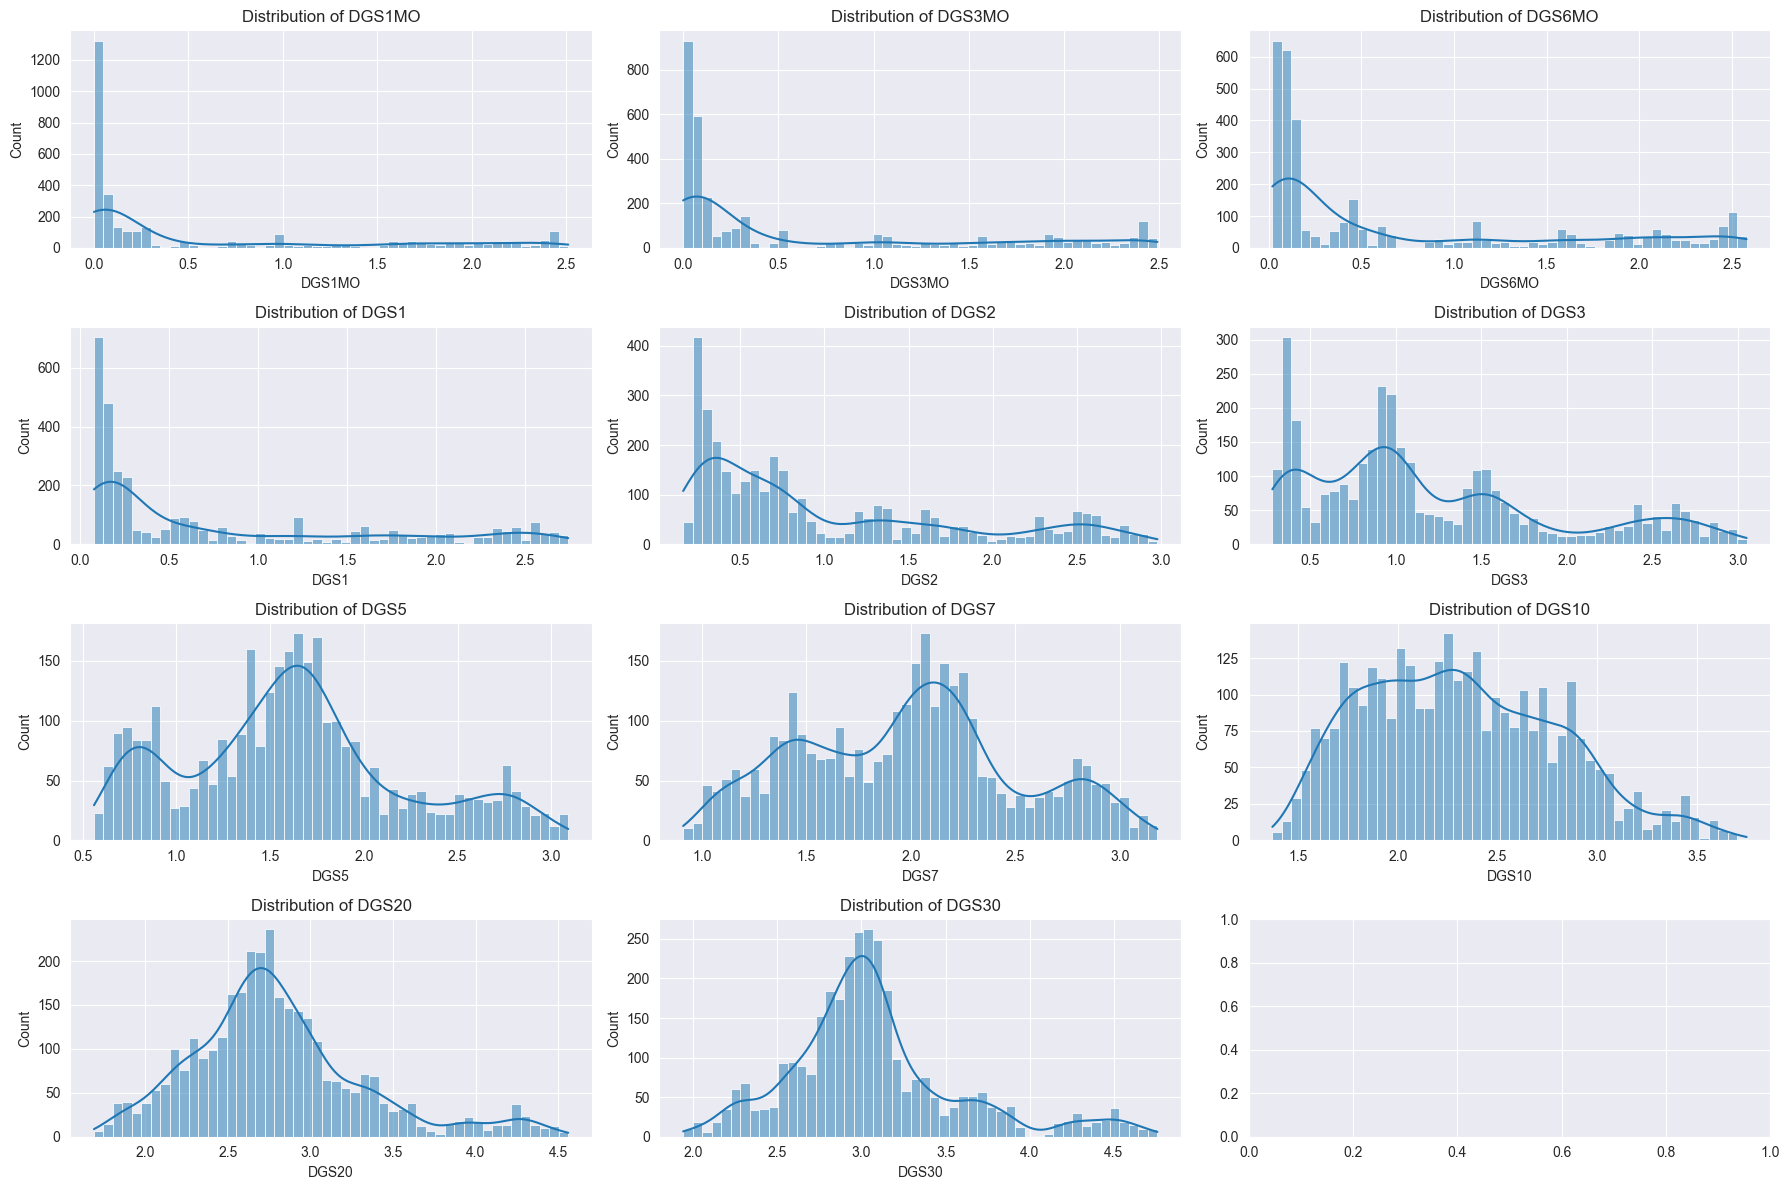

In [6]:
# Create a 6 by 6 subplot visulaizing the distribution of each dependent variable in data_bonds dataframe
fig, axes = plt.subplots(4, 3, figsize=(18, 12))
axes = axes.flatten()
for i, col in enumerate(dependent_varaibles):
    sns.histplot(df_train[col].dropna(), bins=50, kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

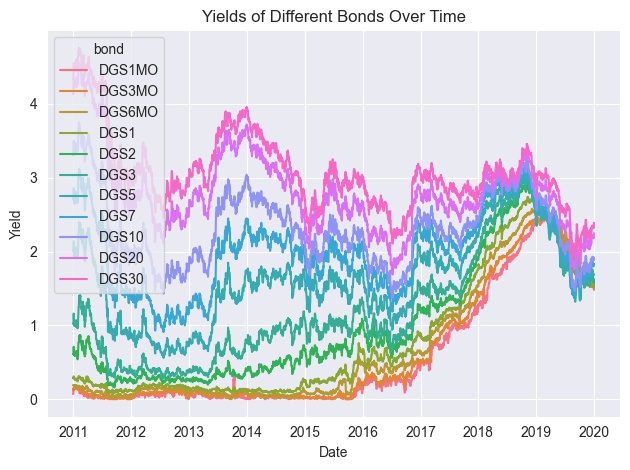

In [94]:
# melt a dataframe of the dependent variables to long format
df_train.index = df_train.index.to_timestamp()
df_melted = df_train[dependent_varaibles].reset_index().melt(id_vars='period', var_name='bond', value_name='yield')
# plot a line plot of the yields of each bond on the same graph using seaborn and the hue parameter
sns.lineplot(data=df_melted, x='period', y='yield', hue='bond')
plt.title('Yields of Different Bonds Over Time')
plt.xlabel('Date')
plt.ylabel('Yield')
plt.tight_layout()
plt.show()

In [29]:
df_melted.dtypes

period    datetime64[ns]
bond              object
yield            float64
dtype: object

In [33]:
# How many independent variables are there?
print("Number of independent variables:", len(independent_variables))

Number of independent variables: 483


In [97]:
df_train2.describe()

,DGS1MO,DGS3MO,DGS6MO,DGS1,DGS2,DGS3,DGS5,DGS7,DGS10,DGS20,...,LNS14000031_diff,LNS14000006_diff,UMCSENT_diff,MICH_diff,VMTD11_diff,M1V_diff,M2V_diff,DEXVZUS_diff,WEI_diff,USAUCSFRCONDOSMSAMID_diff
count,3287.000000,3287.000000,3287.000000,3287.000000,3287.000000,3287.000000,3287.000000,3287.000000,3287.000000,3287.000000,...,3286.000000,3286.000000,3286.000000,3286.000000,3286.000000,3286.000000,3286.000000,3286.000000,3286.000000,3286.000000
mean,0.585939,0.623882,0.702601,0.791734,0.989933,1.193258,1.618993,1.982455,2.314524,2.798372,...,-0.000323,-0.000289,0.000075,-0.000213,0.000073,-0.000880,-0.000093,0.000014,-0.000068,0.000247
std,0.805599,0.822458,0.837222,0.839783,0.781957,0.717736,0.597004,0.525633,0.485342,0.532906,...,0.012779,0.009066,0.006476,0.042271,0.004025,0.014043,0.001590,0.004534,0.011982,0.001714
min,0.000000,0.000000,0.020000,0.080000,0.160000,0.280000,0.560000,0.910000,1.370000,1.690000,...,-0.230000,-0.180000,-0.100000,-0.700000,-0.057640,-0.511000,-0.057000,-0.248207,-0.146000,-0.009116
25%,0.030000,0.040000,0.080000,0.150000,0.350000,0.660000,1.220000,1.550000,1.920000,2.480000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.100000,0.110000,0.160000,0.290000,0.690000,0.990000,1.610000,2.010000,2.270000,2.730000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,1.080000,1.200000,1.315000,1.455000,1.560000,1.920000,2.280000,2.660000,3.030000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,2.510000,2.490000,2.580000,2.740000,2.980000,3.050000,3.090000,3.180000,3.750000,4.560000,...,0.160000,0.100000,0.081000,1.200000,0.084730,0.063000,0.011000,0.041368,0.110000,0.014345


In [10]:
# read in the data definitions
df_macro_info = pd.read_parquet('fred_series.parquet')
non_percent_cols = df_macro_info[(df_macro_info['id'].isin(independent_variables)) & (df_macro_info['units'] != 'Percent')]['id'].tolist()

df_train[non_percent_cols].describe()

# fred_series = {
#     'T5YIE': '5_Year_Inflation_Expectation',
#     'T10YIE': '10_Year_Inflation_Expectation',
#     'T10Y3M': '10_Year_3_Year_Spread',
#     'FEDFUNDS': 'Fed_Funds_Rate',
#     'THREEFYTP10': '10_Year_Term_Premium',
#     'REAINTRATREARAT10Y': '10yr_real_intrest',
#     # 'EFFR': 'Effective_Fed_Funds_Rate_Daily',
#     'CPILFESL': 'CPI_Core',
#     'USEPUINDXD': 'Economic_Policy_Uncertainty_US',
#     'GEPUCURRENT': 'Global_EPU_Index',
#     'REAINTRATREARAT10Y': 'Real_10-Year_Yield',
#     'DFII10': '10_Year_TIPS_Yield',
#     'DGS10': '10_Year_Treasury_Yield',
#     'DTWEXBGS': 'Dollar_Index',
#     'DCOILWTICO': 'Crude_Oil_Price_WTI',
#     'DGS2': '2_Year_Treasury_Yield',
#     'DGS5': '5_Year_Treasury_Yield',
#     'WTISPLC': 'WTI_Spot_price',
#     'INDPRO': 'Industrial_Production',
#     'IPMAN': 'Manufacturing_Production',
#     'CBBTCUSD': 'Bitcoin_spot_price',
#     'M2SL': 'Money_supply',
#     'GVZCLS': 'Gold_Volatility_Index',
#     'M14062USM027NNBR': 'Gold_Reserves_US',
#     'TRESEGUSM052N': 'Gold_Reserves_World',
#     'SP500': 'S&P500_Index',
#     'U2RATE': 'Unemployment_Rate_US',
#     'FDHBFRBN': 'Federal_Debt_Hold_by_Fed',
#     'T10Y2Y': '10yr_2yr_spread',
#     'T10YIE': '10_year_breakeven_inflation',
#     'T5YFF': '5_year_treasury_fed_funds',
#     'TB3SMFFM': '3yr_t_bill_spread',
#     'MORTGAGE30US': '30yr_mortgage_rate',
#     'MORTGAGE15US': '15yr_mortgage_rate',
#     'OBMMIFHA30YF': '30yr_fixed_fha',
#     'TB3MS': '3mth_treasury',
#     'EXUSEU': 'us_euro_exchange_rate',
#     'EXJPUS': 'japan_usd_exchange_rate',
#     'EXCHUS': 'china_usd_exchange_rate',
#     'EXCAUS': 'canada_usd_exchange_rate',
#     'EXUSUK': 'uk_usd_exchange_rate',
#     'EXKOUS': 'skorea_usd_exchange_rate',
#     'EXBZUS': 'brazil_usd_exchange_rate',
#     'EXMXUS': 'mex_usd_exchange_rate',
#     'EXINUS': 'india_usd_exchange_rate',
#     'EXUSAL': 'aus_usd_exchange_rate',
#     'EXSDUS': 'swd_usd_exchange_rate',
#     'EXSGUS': 'sweden_usd_exchange_rate',
#     'EXSIUS': 'singapore_usd_exchange_rate',
#     'EXSFUS': 'safrice_usd_exchange_rate',
#     'DTWEXBGS': 'us_dollar_index',
#     'RTWEXBGS': 'broad_dollar_index',
#     'SWPT': 'cc_bank_liquidity_swps',
#     'WRESBAL': 'liabilities_reserve_bank',
#     'BORROW': 'total_borrowing',
#     'TOTRESNS': 'reserves_deposit_institutions',
#     'ADPWINDINFONERSA': 'employement_information',
#     'ADPWINDPROBUSNERSA': 'unemployment_business',
#     'TENEXPCHAREARISPRE': 'real_risk_premium',
#     'STLPPM': 'price_pressure',
#     'TENEXPCHAINFRISPRE': 'inflation_risk_premium',
#     'IR': 'import_price_index',
#     'IR14270': 'import_price_index_non_money',
#     'IR10000': 'import_price_oil',
#     'IQ12260': 'export_non_money',
#     'IQ': 'export_price_index',
#     'MVGFD027MNFRBDAL': 'market_val_fed_debt',
#     'MTSMFBP133FMS': 'borrow_public',
# }
#
# cols = list(fred_series.keys())
# print(f"Length of Terrill's Columns: {len(cols)}")
# df_macro_info[df_macro_info['id'].isin(cols)].shape

,IC4WSA,RRSFS,MARTSMPCSM44000USS,MARTSMPCSM44X72USS,CES4348100001,USCONS,USFIRE,USGOVT,USINFO,USLAH,...,GASDESW,GASREGW,UNEMPLOY,UMCSENT,VMTD11,M1V,M2V,DEXVZUS,WEI,USAUCSFRCONDOSMSAMID
count,3287.000000,3287.000000,3287.000000,3287.000000,3287.000000,3287.000000,3287.000000,3287.000000,3287.000000,3287.000000,...,3287.000000,3287.000000,3287.000000,3287.000000,3287.000000,3287.000000,3287.000000,3287.000000,3287.000000,3287.000000
mean,296025.631275,183266.876787,0.302738,0.329845,470.433739,6457.271372,8171.473684,22155.745665,2759.535443,15092.445391,...,3.273660,2.925298,9183.863097,86.999148,258432.720718,6.257279,1.527926,6421.817618,2.233347,199783.573644
std,65879.486559,10142.252948,0.672663,0.613517,21.997210,676.543657,352.384289,261.275579,67.647599,1092.786421,...,0.618201,0.581637,2669.561659,10.781810,9894.913886,0.732136,0.079972,24094.664119,0.497899,28483.135987
min,201500.000000,164184.000000,-2.200000,-2.000000,439.300000,5427.000000,7676.000000,21814.000000,2632.000000,13149.000000,...,1.980000,1.724000,5753.000000,55.800000,243131.000000,5.526000,1.437000,2.482100,0.610000,162081.905424
25%,239500.000000,174884.000000,-0.100000,0.000000,453.200000,5802.000000,7864.000000,21916.000000,2696.000000,14132.500000,...,2.788000,2.403000,6854.000000,78.600000,249145.000000,5.626500,1.459000,6.284200,1.940000,171058.693180
50%,277500.000000,184752.000000,0.300000,0.300000,461.100000,6472.000000,8134.000000,22097.000000,2751.000000,15168.000000,...,3.217000,2.827000,8167.000000,90.000000,257796.000000,6.075000,1.521000,6.284200,2.260000,196668.970693
75%,352000.000000,193042.000000,0.700000,0.800000,493.900000,7013.000000,8479.000000,22361.000000,2817.000000,16140.000000,...,3.888000,3.496000,11751.000000,96.200000,267900.000000,6.688000,1.576500,9.975000,2.570000,223462.060042
max,435000.000000,200191.000000,2.300000,2.100000,513.100000,7553.000000,8823.000000,22726.000000,2891.000000,16805.000000,...,4.159000,3.965000,14348.000000,101.400000,277525.000000,8.434000,1.741000,248209.921900,4.270000,252026.519093


In [98]:
# create a function that will scale each column down so the max value is single digits
# def scale_to_single_digits(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
#     """
#     Scale each column down so the max value is single digits
#     """
#     # iterate through each column
#     for col in cols:
#         max_val = df[col].max()
#         if pd.isna(max_val) or max_val == 0:
#             continue
#         scale_factor = 10 ** (len(str(int(max_val))) - 1)
#         df[col] = df[col] / scale_factor
#         df[col].describe()
#     return df

# data_bonds2 = scale_to_single_digits(df=data_bonds, cols=independent_variables)
df_train2 = scale_to_single_digits(df=df_train, cols=independent_variables)
df_test2 = scale_to_single_digits(df=df_test, cols=independent_variables)
df_train2


/var/folders/h3/n4kr77l914l79rj692skv4jw0000gn/T/ipykernel_70633/3467258630.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col] / scale_factor
/var/folders/h3/n4kr77l914l79rj692skv4jw0000gn/T/ipykernel_70633/3467258630.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col] / scale_factor
/var/folders/h3/n4kr77l914l79rj692skv4jw0000gn/T/ipykernel_70633/3467258630.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .lo

,DGS1MO,DGS3MO,DGS6MO,DGS1,DGS2,DGS3,DGS5,DGS7,DGS10,DGS20,...,LNS14000031_diff,LNS14000006_diff,UMCSENT_diff,MICH_diff,VMTD11_diff,M1V_diff,M2V_diff,DEXVZUS_diff,WEI_diff,USAUCSFRCONDOSMSAMID_diff
period,,,,,,,,,,,,,,,,,,,,,
2011-01-01,0.07,0.12,0.19,0.29,0.61,1.02,2.01,2.71,3.30,4.13,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-01-02,0.07,0.12,0.19,0.29,0.61,1.02,2.01,2.71,3.30,4.13,...,0.04,0.03,-0.003,0.4,0.01911,-0.229,-0.017,0.000000e+00,-0.067,-0.009116
2011-01-03,0.11,0.15,0.19,0.29,0.61,1.03,2.02,2.74,3.36,4.18,...,0.00,0.00,0.000,0.0,0.00000,0.000,0.000,0.000000e+00,0.000,0.000000
2011-01-04,0.12,0.14,0.19,0.28,0.63,1.04,2.01,2.72,3.36,4.21,...,0.00,0.00,0.000,0.0,0.00000,0.000,0.000,0.000000e+00,0.000,0.000000
2011-01-05,0.13,0.14,0.19,0.31,0.71,1.16,2.14,2.86,3.50,4.34,...,0.00,0.00,0.000,0.0,0.00000,0.000,0.000,0.000000e+00,0.000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-12-27,1.56,1.57,1.59,1.51,1.59,1.60,1.68,1.80,1.88,2.18,...,0.00,0.00,0.000,0.0,0.00000,0.000,0.000,-1.600000e-09,0.000,0.000000
2019-12-28,1.56,1.57,1.59,1.51,1.59,1.60,1.68,1.80,1.88,2.18,...,0.00,0.00,0.000,0.0,0.00000,0.000,0.000,-2.950940e-04,0.000,0.000000
2019-12-29,1.56,1.57,1.59,1.51,1.59,1.60,1.68,1.80,1.88,2.18,...,0.00,0.00,0.000,0.0,0.00000,0.000,0.000,0.000000e+00,0.000,0.000000


In [99]:
# detrend the dataset by taking the difference between the current value and the value 1 day ago
# create an empty dataframe with the same index as df_train2 and df_test2
df_train_diff = pd.DataFrame(index=df_train2.index)
df_test_diff = pd.DataFrame(index=df_test2.index)
for col in df_train2.columns:
    df_train_diff[f'{col}'] = df_train2[col] - df_train2[col].shift(1)
    df_test_diff[f'{col}'] = df_test2[col] - df_test2[col].shift(1)

df_test_diff.describe()

/var/folders/h3/n4kr77l914l79rj692skv4jw0000gn/T/ipykernel_70633/2821272931.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_train_diff[f'{col}'] = df_train2[col] - df_train2[col].shift(1)
/var/folders/h3/n4kr77l914l79rj692skv4jw0000gn/T/ipykernel_70633/2821272931.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_test_diff[f'{col}'] = df_test2[col] - df_test2[col].shift(1)
/var/folders/h3/n4kr77l914l79rj692skv4jw0000gn/T/ipykernel_70633/2821272931.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usua

,DGS1MO,DGS3MO,DGS6MO,DGS1,DGS2,DGS3,DGS5,DGS7,DGS10,DGS20,...,LNS14000031_diff,LNS14000006_diff,UMCSENT_diff,MICH_diff,VMTD11_diff,M1V_diff,M2V_diff,DEXVZUS_diff,WEI_diff,USAUCSFRCONDOSMSAMID_diff
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,...,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1.459000e+03,1459.000000,1459.000000
mean,0.002822,0.002637,0.002507,0.002192,0.001815,0.001637,0.001473,0.001404,0.001342,0.001336,...,-0.000007,-0.000027,-0.000003,-0.000137,-0.000113,0.000154,0.000032,9.376782e-19,-0.000027,-0.000011
std,0.058366,0.034150,0.033928,0.044714,0.054552,0.055913,0.056026,0.055637,0.053222,0.051141,...,0.039929,0.040027,0.013885,0.123839,0.037160,0.138740,0.010393,1.548737e-01,0.034438,0.007896
min,-0.710000,-0.230000,-0.360000,-0.600000,-0.570000,-0.430000,-0.320000,-0.310000,-0.300000,-0.260000,...,-0.940000,-0.990000,-0.173000,-1.400000,-0.591700,-3.727000,-0.262000,-4.133440e+00,-0.275000,-0.064055
25%,0.000000,0.000000,0.000000,0.000000,-0.010000,-0.010000,-0.010000,-0.010000,-0.020000,-0.020000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-7.155000e-08,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000
75%,0.000000,0.010000,0.010000,0.010000,0.010000,0.010000,0.020000,0.020000,0.020000,0.020000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.845000e-08,0.000000,0.000000
max,1.060000,0.340000,0.270000,0.340000,0.340000,0.350000,0.310000,0.290000,0.290000,0.350000,...,0.940000,0.990000,0.173000,1.400000,0.591700,3.727000,0.262000,4.133440e+00,0.275000,0.064055


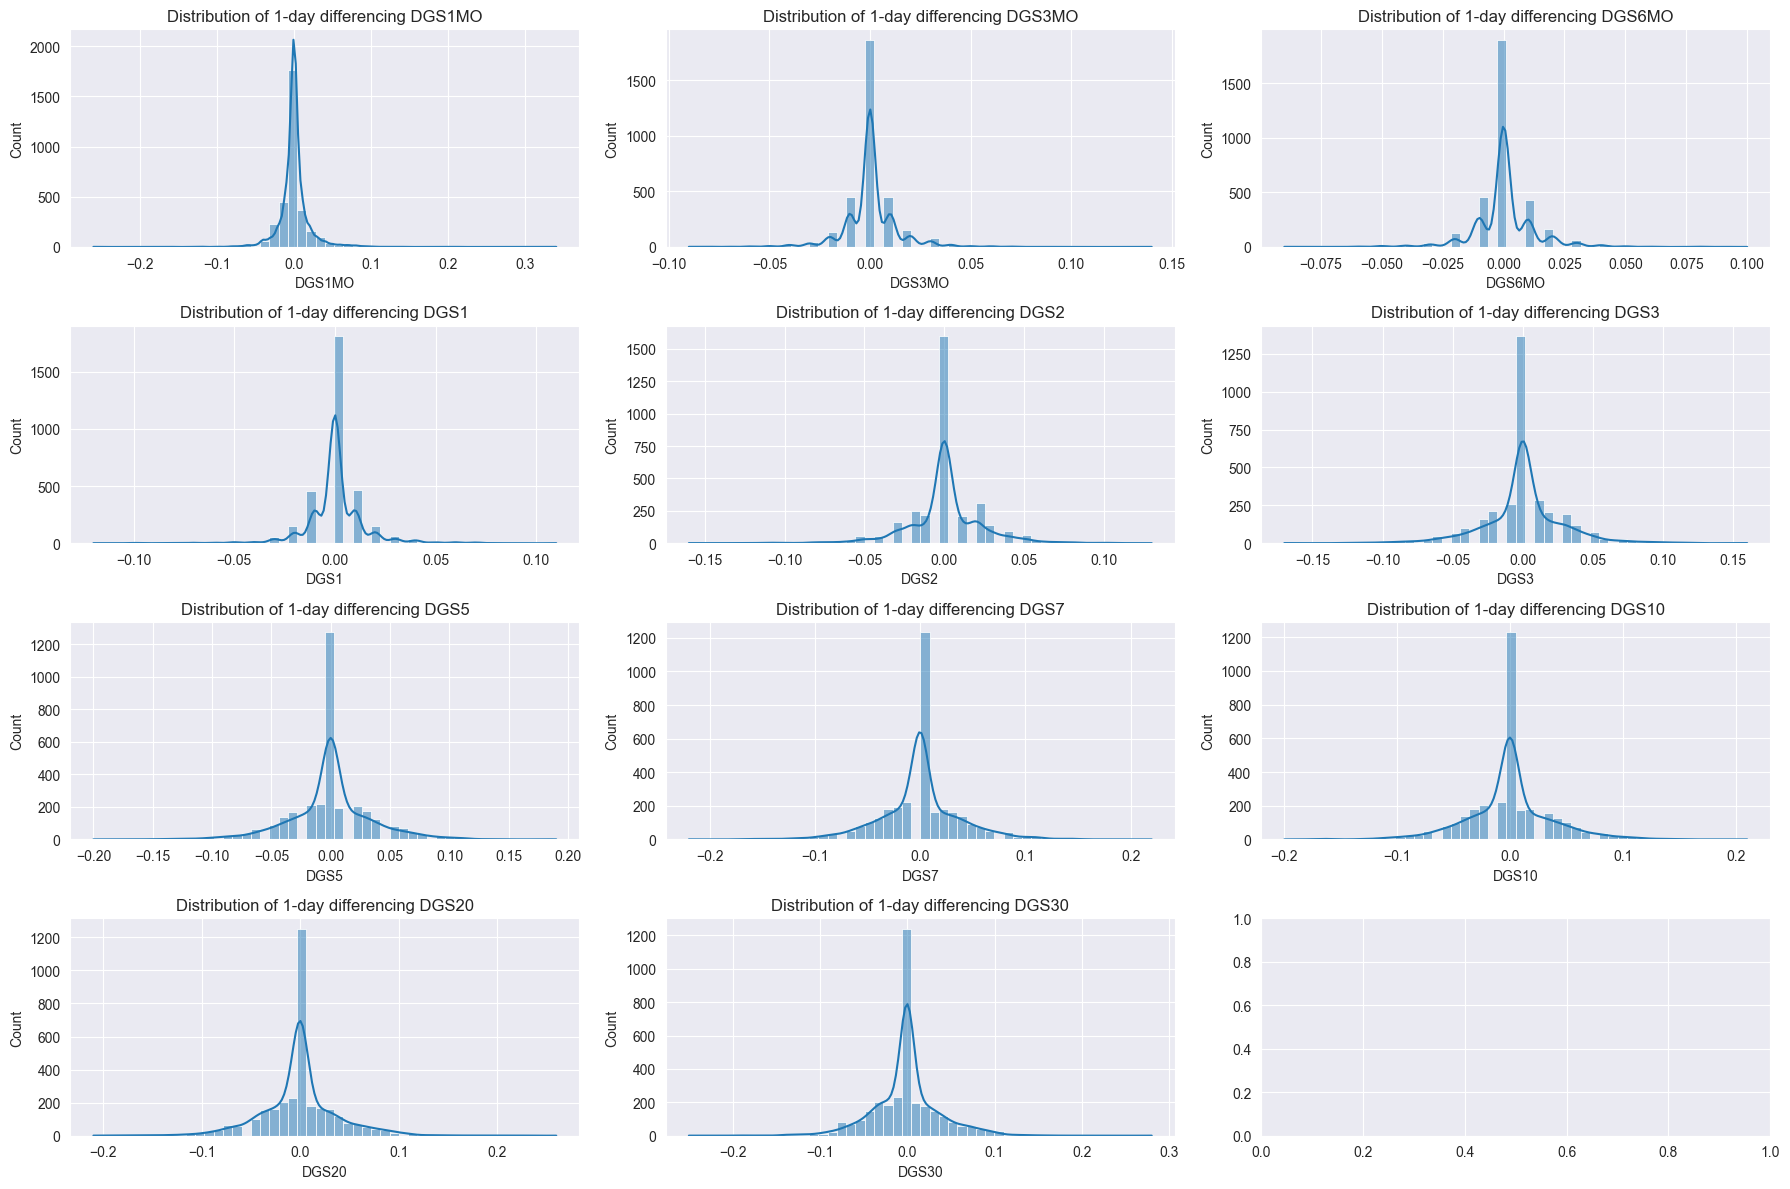

In [101]:
fig, axes = plt.subplots(4, 3, figsize=(18, 12))
axes = axes.flatten()
for i, col in enumerate(dependent_varaibles):
    sns.histplot(df_train_diff[col].dropna(), bins=50, kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of 1-day differencing {col}')
plt.tight_layout()
plt.show()

In [21]:
fred_series = {
    'T5YIE': '5_Year_Inflation_Expectation',
    'T10YIE': '10_Year_Inflation_Expectation',
    'T10Y3M': '10_Year_3_Year_Spread',
    'FEDFUNDS': 'Fed_Funds_Rate',
    'THREEFYTP10': '10_Year_Term_Premium',
    'REAINTRATREARAT10Y': '10yr_real_intrest',
    'CPILFESL': 'CPI_Core',
    'USEPUINDXD': 'Economic_Policy_Uncertainty_US',
    'GEPUCURRENT': 'Global_EPU_Index',
    'REAINTRATREARAT10Y': 'Real_10-Year_Yield',
    'DFII10': '10_Year_TIPS_Yield',
    'DGS10': '10_Year_Treasury_Yield',
    'DTWEXBGS': 'Dollar_Index',
    'DCOILWTICO': 'Crude_Oil_Price_WTI',
    'DGS2': '2_Year_Treasury_Yield',
    'DGS5': '5_Year_Treasury_Yield',
    'WTISPLC': 'WTI_Spot_price',
    'INDPRO': 'Industrial_Production',
    'IPMAN': 'Manufacturing_Production',
    'CBBTCUSD': 'Bitcoin_spot_price',
    'M2SL': 'Money_supply',
    'GVZCLS': 'Gold_Volatility_Index',
    'M14062USM027NNBR': 'Gold_Reserves_US',
    'TRESEGUSM052N': 'Gold_Reserves_World',
    'SP500': 'S&P500_Index',
    'U2RATE': 'Unemployment_Rate_US',
    'FDHBFRBN': 'Federal_Debt_Hold_by_Fed',
    'T10Y2Y': '10yr_2yr_spread',
    'T10YIE': '10_year_breakeven_inflation',
    'T5YFF': '5_year_treasury_fed_funds',
    'TB3SMFFM': '3yr_t_bill_spread',
    'MORTGAGE30US': '30yr_mortgage_rate',
    'MORTGAGE15US': '15yr_mortgage_rate',
    'OBMMIFHA30YF': '30yr_fixed_fha',
    'TB3MS': '3mth_treasury',
    'EXUSEU': 'us_euro_exchange_rate',
    'EXJPUS': 'japan_usd_exchange_rate',
    'EXCHUS': 'china_usd_exchange_rate',
    'EXCAUS': 'canada_usd_exchange_rate',
    'EXUSUK': 'uk_usd_exchange_rate',
    'EXKOUS': 'skorea_usd_exchange_rate',
    'EXBZUS': 'brazil_usd_exchange_rate',
    'EXMXUS': 'mex_usd_exchange_rate',
    'EXINUS': 'india_usd_exchange_rate',
    'EXUSAL': 'aus_usd_exchange_rate',
    'EXSDUS': 'swd_usd_exchange_rate',
    'EXSGUS': 'sweden_usd_exchange_rate',
    'EXSIUS': 'singapore_usd_exchange_rate',
    'EXSFUS': 'safrice_usd_exchange_rate',
    'DTWEXBGS': 'us_dollar_index',
    'RTWEXBGS': 'broad_dollar_index',
    'SWPT': 'cc_bank_liquidity_swps',
    'WRESBAL': 'liabilities_reserve_bank',
    'BORROW': 'total_borrowing',
    'TOTRESNS': 'reserves_deposit_institutions',
    'ADPWINDINFONERSA': 'employement_information',
    'ADPWINDPROBUSNERSA': 'unemployment_business',
    'TENEXPCHAREARISPRE': 'real_risk_premium',
    'STLPPM': 'price_pressure',
    'TENEXPCHAINFRISPRE': 'inflation_risk_premium',
    'IR': 'import_price_index',
    'IR14270': 'import_price_index_non_money',
    'IR10000': 'import_price_oil',
    'IQ12260': 'export_non_money',
    'IQ': 'export_price_index',
    'MVGFD027MNFRBDAL': 'market_val_fed_debt',
    'MTSMFBP133FMS': 'borrow_public',
}

# Get the set of keys that are in independent_variables and fred_series
cols = list(set(independent_variables) & set(fred_series.keys()))
print(f"Length of Terrill's Columns: {len(cols)}")
# get the set of keys that are not in dependent_variables
print(cols)

Length of Terrill's Columns: 21
['DCOILWTICO', 'CPILFESL', 'T10Y2Y', 'USEPUINDXD', 'WRESBAL', 'DFII10', 'REAINTRATREARAT10Y', 'INDPRO', 'IPMAN', 'MORTGAGE15US', 'T10Y3M', 'DTWEXBGS', 'RTWEXBGS', 'T10YIE', 'THREEFYTP10', 'SWPT', 'TOTRESNS', 'FDHBFRBN', 'MORTGAGE30US', 'T5YIE', 'WTISPLC']


In [103]:
# Create a dataframe to store the correlation results between each independent variable and each dependent variable
rows = []
counter = 0
for dependent_var in tqdm(dependent_varaibles):
    for independent_var in independent_variables:
        # get the correlation value between the two variables
        corr_val = df_train_diff[[dependent_var, independent_var]].corr()
        corr_val = corr_val.loc[dependent_var, independent_var]
        # print(f"Correlation between {dependent_var} and {independent_var}: {corr_val}")
        rows.append({
            'dependent_variable': dependent_var,
            'independent_variable': independent_var,
            'correlation': corr_val
        })

df_correlation = pd.DataFrame(rows)
# get the groupby count by dependent_variable
df_correlation_count = df_correlation['dependent_variable'].value_counts().reset_index()
df_correlation_count.columns = ['dependent_variable', 'count']
df_correlation_count = df_correlation_count.sort_values(by='count', ascending=False)
df_correlation_count.head(15)

100%|██████████| 11/11 [00:03<00:00,  3.25it/s]


,dependent_variable,count
0,DGS1MO,483
1,DGS3MO,483
2,DGS6MO,483
3,DGS1,483
4,DGS2,483
5,DGS3,483
6,DGS5,483
7,DGS7,483
8,DGS10,483
9,DGS20,483


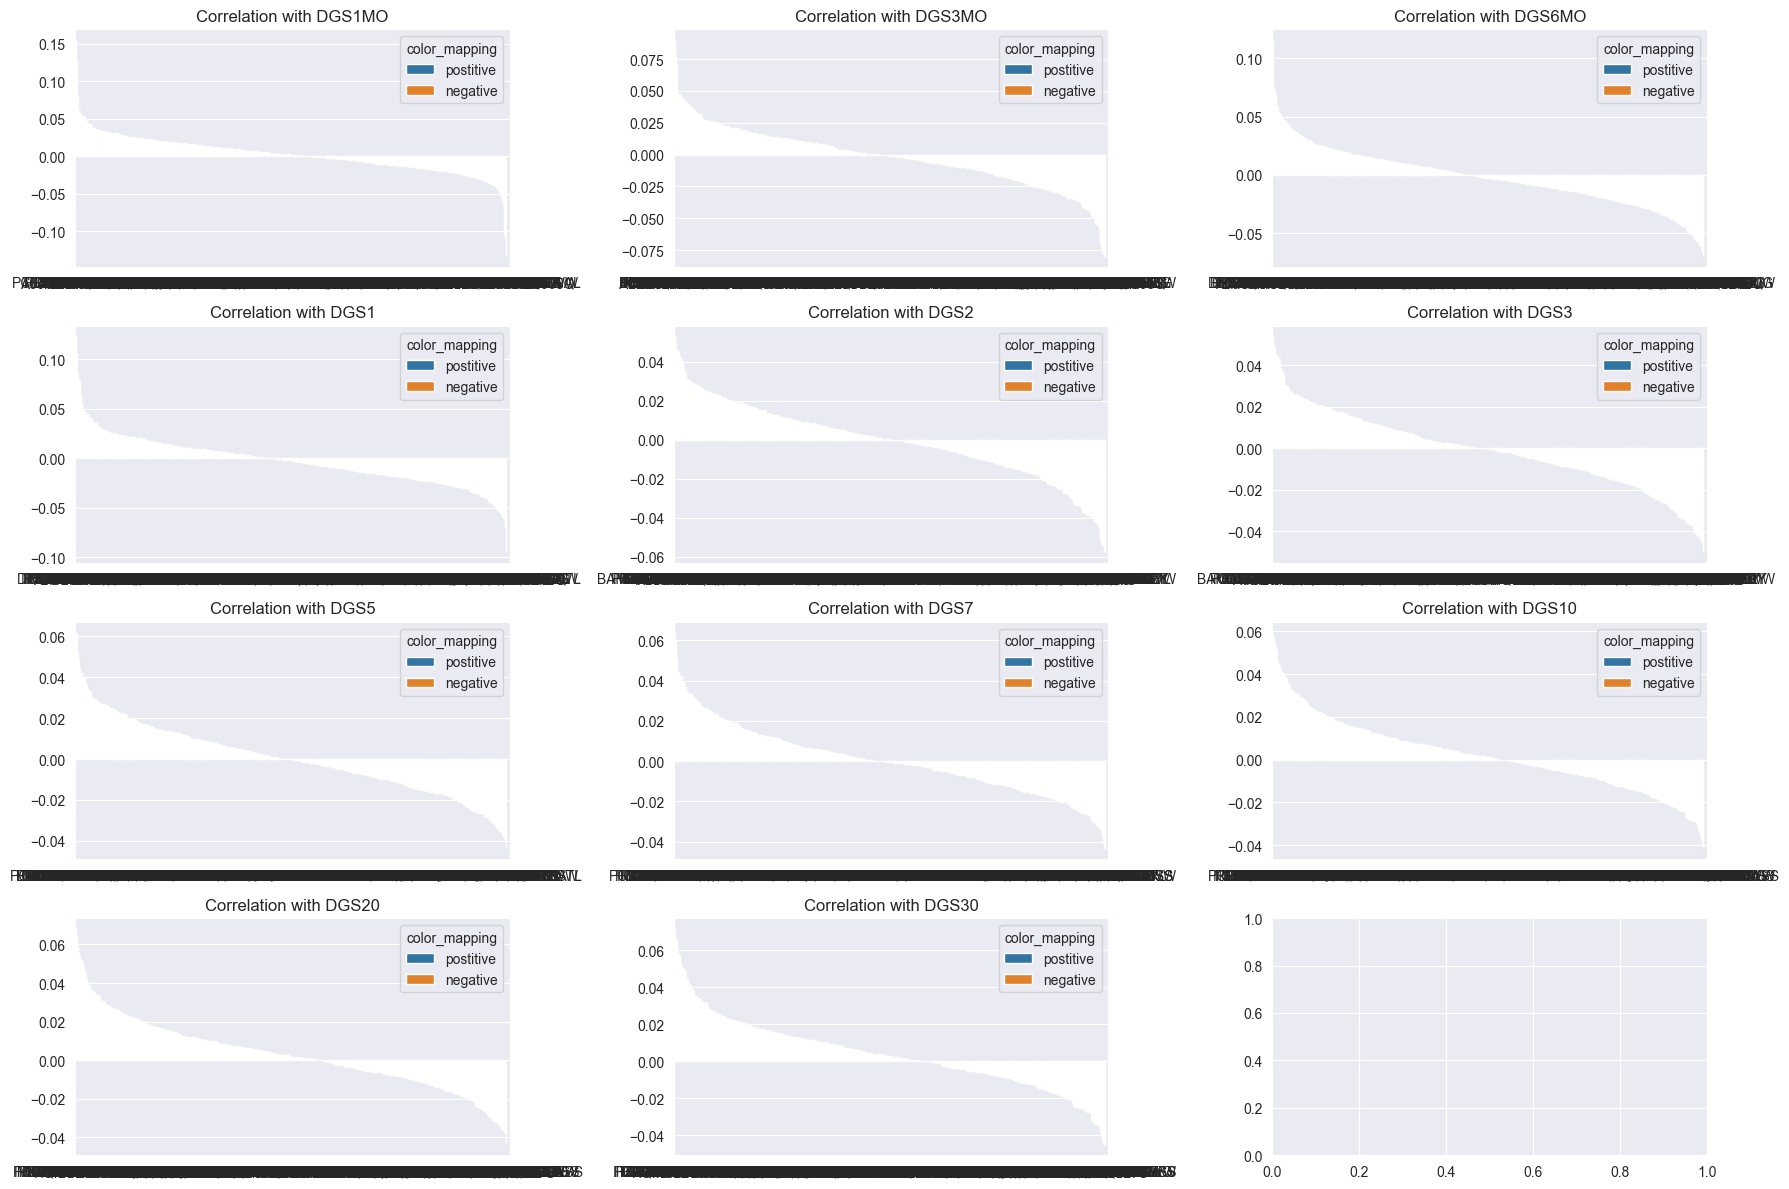

In [104]:
# Sort the correlation dataframe by correlation value in descending order
df_correlation_sorted = df_correlation.sort_values(by='correlation', ascending=False)
df_correlation_sorted['color_mapping'] = df_correlation_sorted['correlation'].apply(lambda x: 'postitive' if x > 0 else 'negative')
# Plot the correlation values using seaborn barplot. Remove x labels. Use green for correlations above 0 and red for those less than. Do this for each dependent variable by creating a 6 by 6 subplot

fig, axes = plt.subplots(4, 3, figsize=(18, 12))
axes = axes.flatten()
for i, dependent_var in enumerate(dependent_varaibles):
    df_tmp = df_correlation_sorted[df_correlation_sorted['dependent_variable'] == dependent_var]
    sns.barplot(data=df_tmp, x='independent_variable', y='correlation', hue='color_mapping', ax=axes[i])
    axes[i].set_title(f'Correlation with {dependent_var}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
plt.tight_layout()

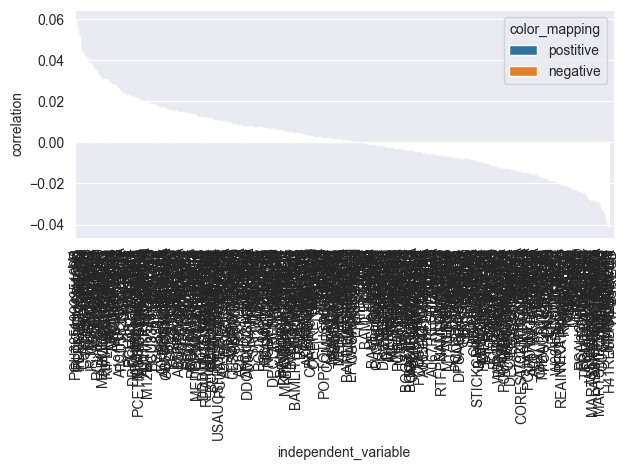

In [105]:
df_tmp = df_correlation_sorted[df_correlation_sorted['dependent_variable'] == 'DGS10']
sns.barplot(data=df_tmp, x='independent_variable', y='correlation', hue='color_mapping')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [106]:
# get the values that are above 0.6 or below -0.6
# df_correlation_extreme = df_correlation_sorted[(df_correlation_sorted['correlation'] >= 0.6) | (df_correlation_sorted['correlation'] <= -0.6)]
#
# # For each depedent variable, plot the correlation matrix between the values that are above 0.6 or below -0.6
# fig, axes = plt.subplots(4, 3, figsize=(22, 20))
# axes = axes.flatten()
# for i, dependent_var in enumerate(dependent_varaibles):
#     df_tmp = df_correlation_extreme[df_correlation_extreme['dependent_variable'] == dependent_var]
#     corr_columns = df_tmp['independent_variable'].tolist() + [dependent_var]
#     df_corr_matrix = df_train[corr_columns].corr()
#     sns.heatmap(df_corr_matrix, fmt=".2f", cmap='coolwarm', center=0, ax=axes[i])
#     axes[i].set_title(f'Correlation Matrix for {dependent_var}')
# plt.tight_layout()

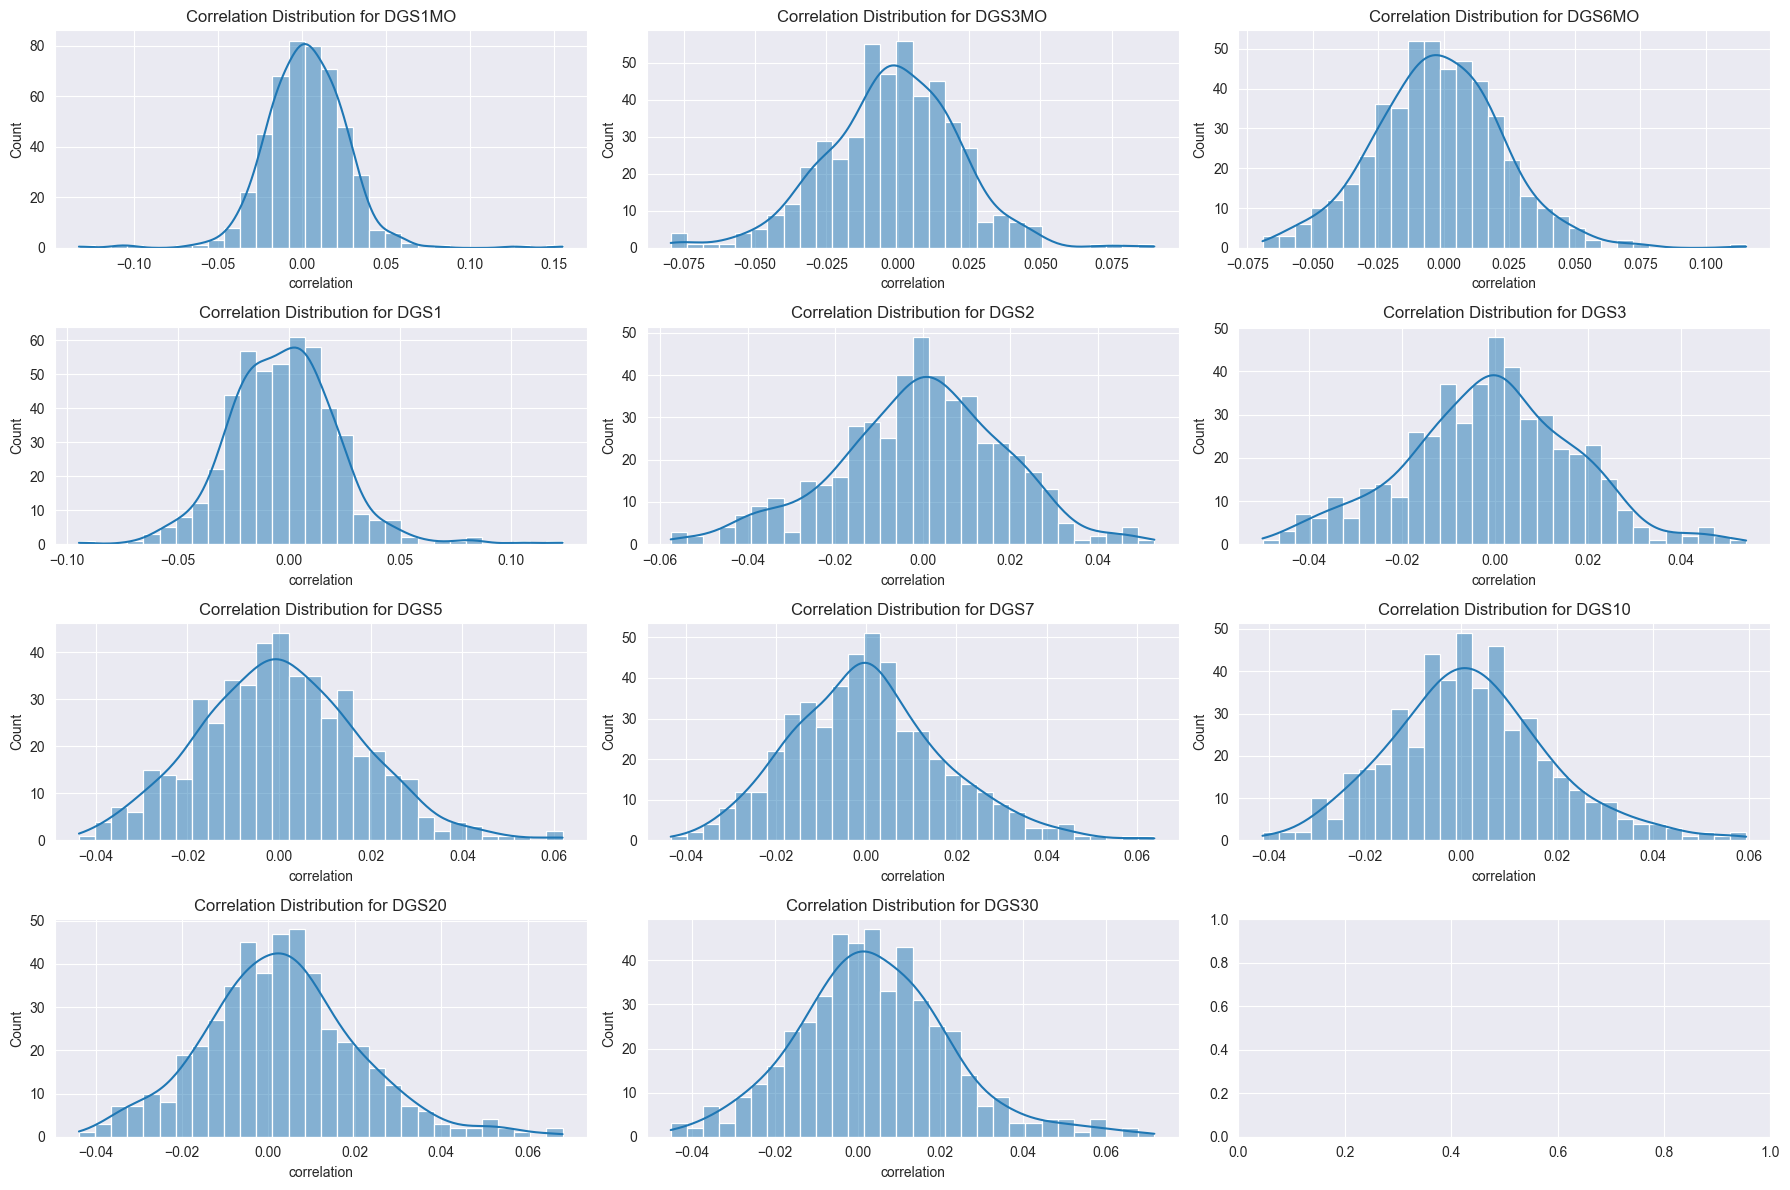

In [107]:
# plot the distribttion of correlations for each dependent variable using seaborn histplot in a 6 by 6 subplot
fig, axes = plt.subplots(4, 3, figsize=(18, 12))
axes = axes.flatten()
for i, dependent_var in enumerate(dependent_varaibles):
    df_tmp = df_correlation_sorted[df_correlation_sorted['dependent_variable'] == dependent_var]
    sns.histplot(data=df_tmp, x='correlation', bins=30, kde=True, ax=axes[i])
    axes[i].set_title(f'Correlation Distribution for {dependent_var}')
plt.tight_layout()


In [119]:
# TO:DO run PCA once and pass all the dependent variables to the fit function and pass only the independent variables to the fit function
# # run PCA on the independent variables for each dependent variable
df_tmp = df_train_diff.dropna()
pca = PCA(n_components=0.95, svd_solver='full').fit(X=df_tmp[independent_variables])
# Capture the metrics and the transformed data
pca_vals = pca.transform(X=df_tmp[independent_variables])
pca_columns = [f'PC{i+1}' for i in range(pca.n_components_)]
df_pca = pd.DataFrame(pca_vals, columns=pca_columns, index=df_tmp.index)
# add the dependent variable back to the dataframe
df_pca[dependent_varaibles] = df_tmp[dependent_varaibles].values


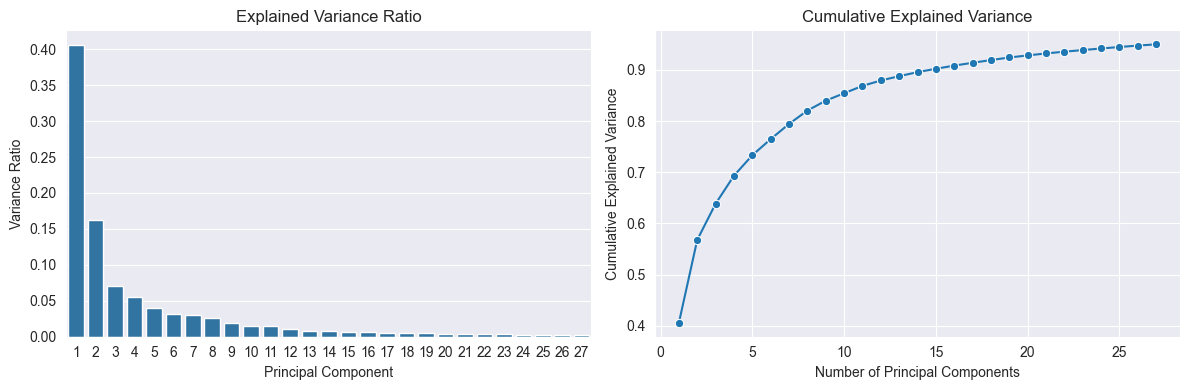

In [120]:
# for each dependent variable, plot the explained variance ratio and cumulative explained variance
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for i in range(2):
    if i == 0:
        sns.barplot(x=range(1, len(pca.explained_variance_ratio_)+1), y=pca.explained_variance_ratio_, ax=axes[i])
        axes[i].set_title('Explained Variance Ratio')
        axes[i].set_xlabel('Principal Component')
        axes[i].set_ylabel('Variance Ratio')
    else:
        cumulative_explained_variance = np.cumsum(pca.explained_variance_ratio_)
        sns.lineplot(x=range(1, len(cumulative_explained_variance)+1), y=cumulative_explained_variance, marker='o', ax=axes[i])
        axes[i].set_title('Cumulative Explained Variance')
        axes[i].set_xlabel('Number of Principal Components')
        axes[i].set_ylabel('Cumulative Explained Variance')
plt.tight_layout()


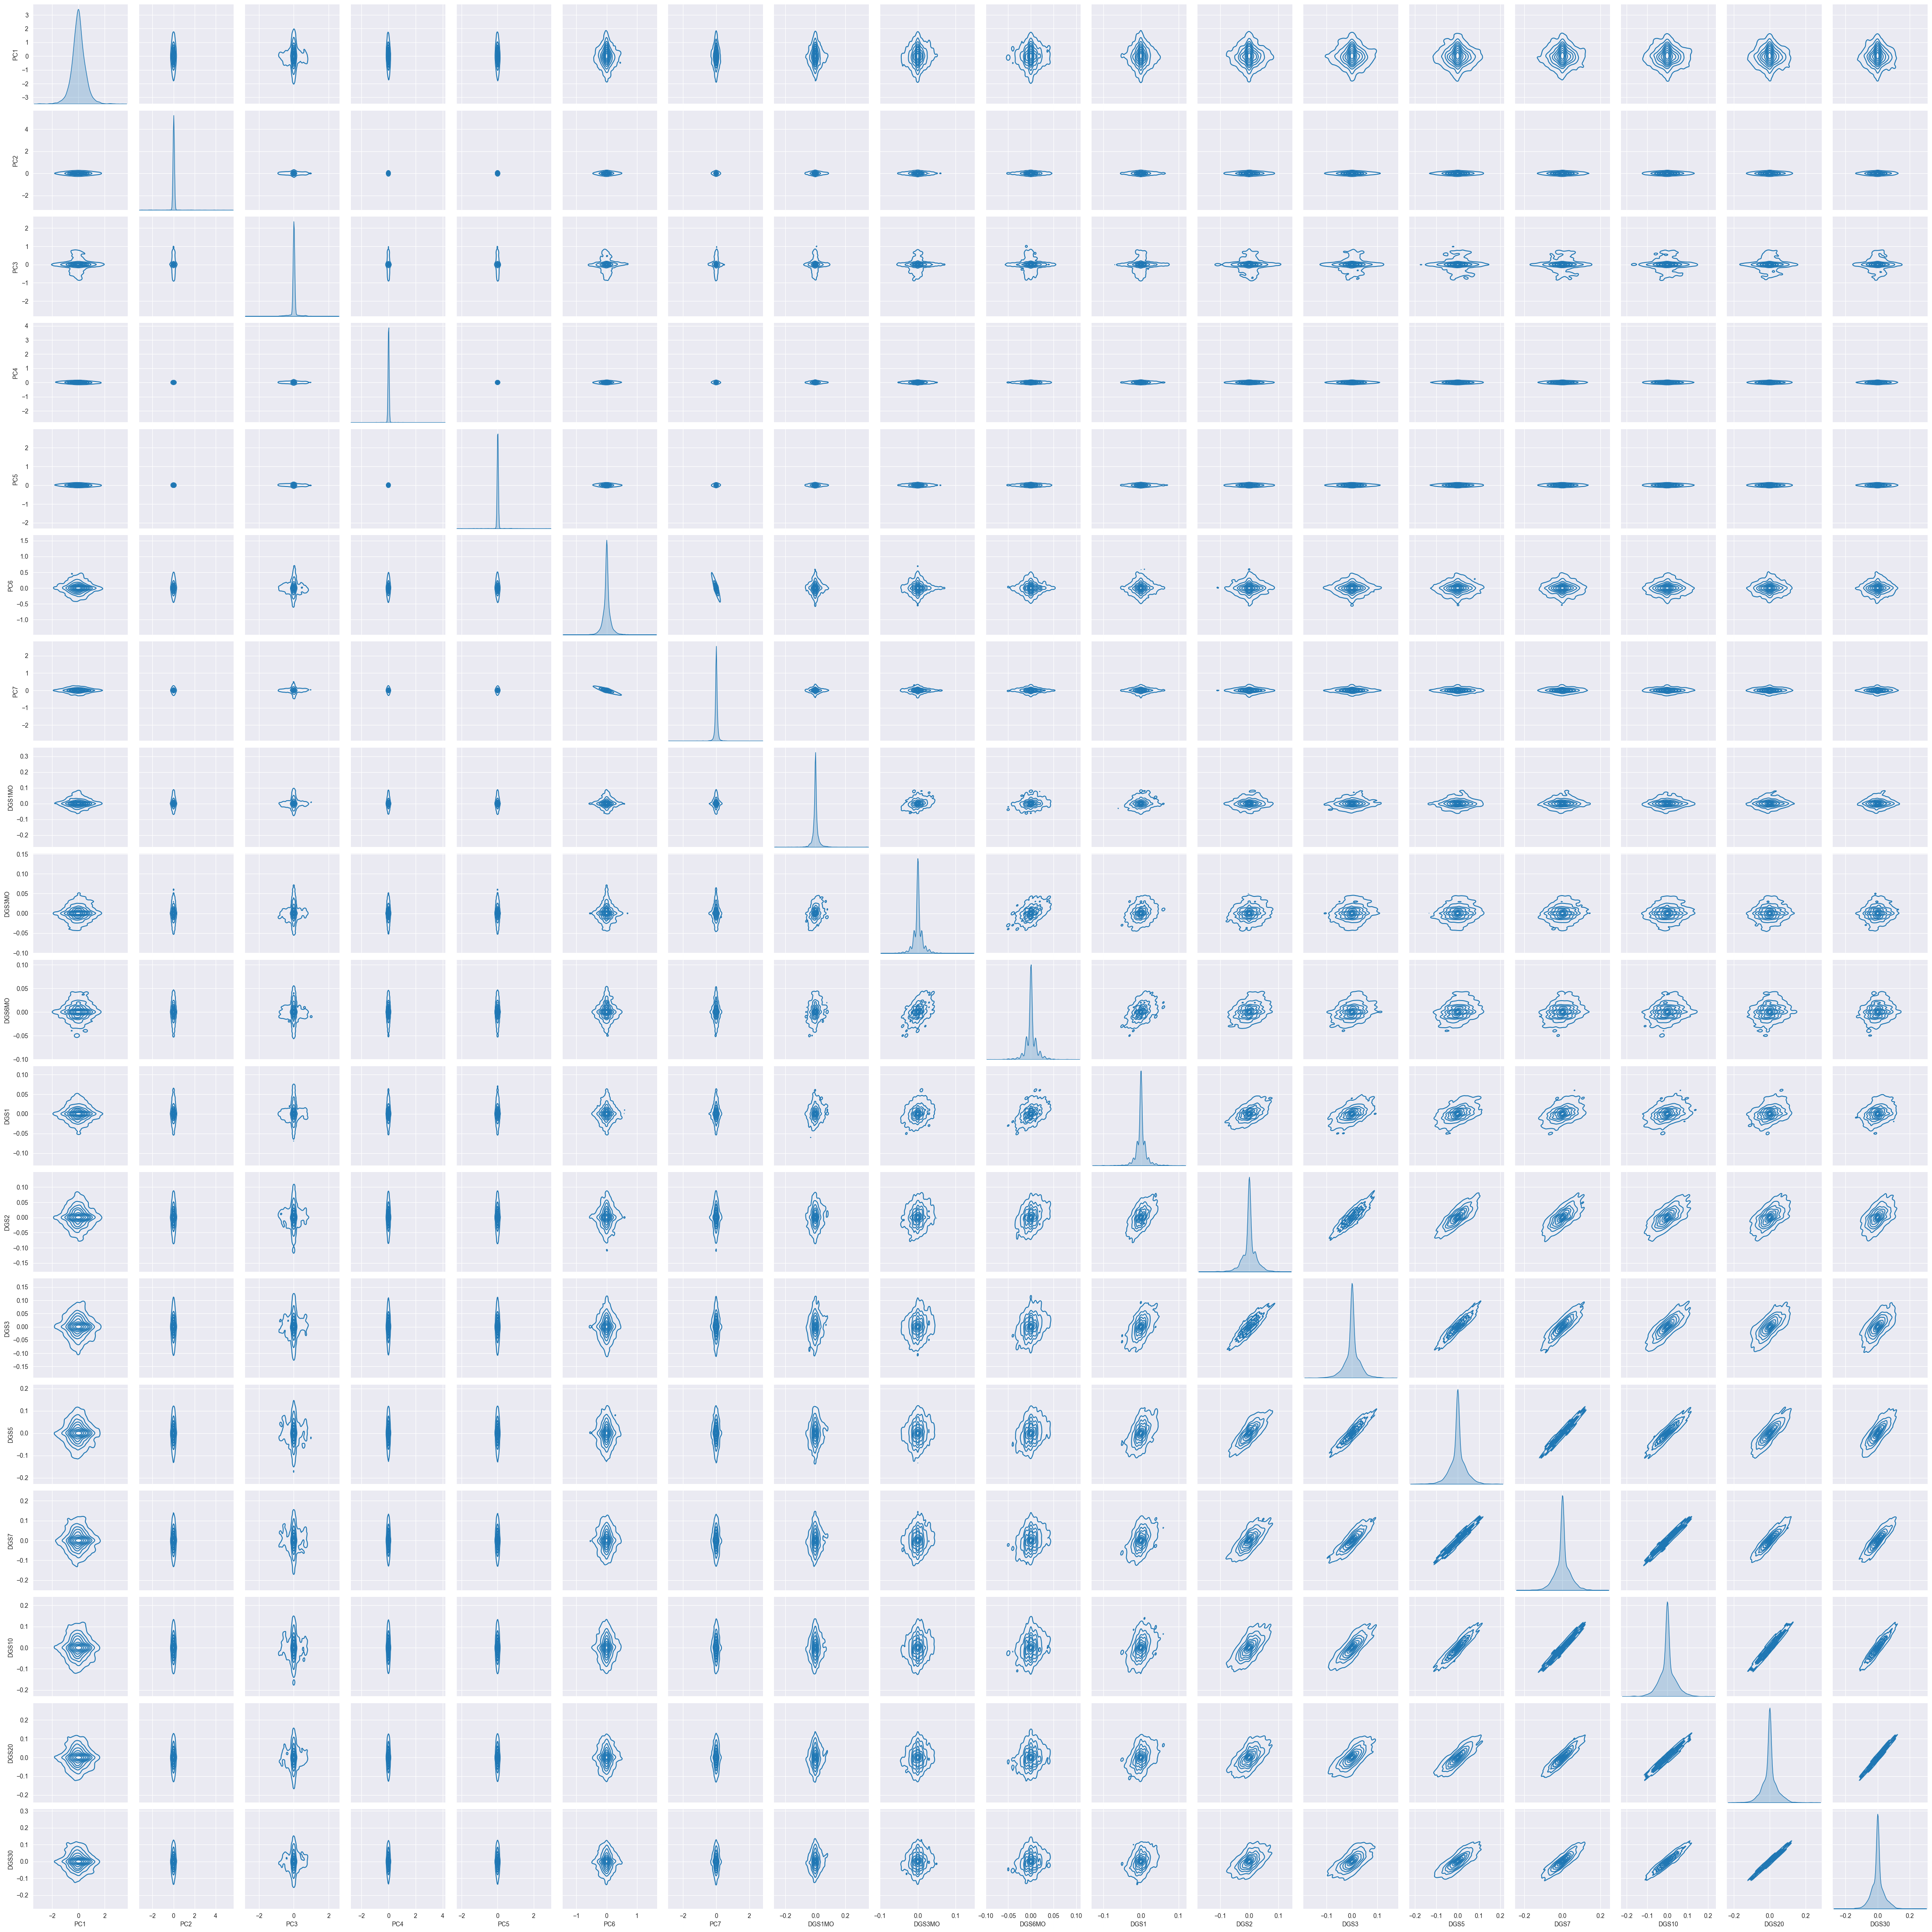

In [122]:
plot_cols = pca_columns[:7] + dependent_varaibles
sns.pairplot(df_pca[plot_cols], kind='kde')

IndexError: index 16 is out of bounds for axis 0 with size 16

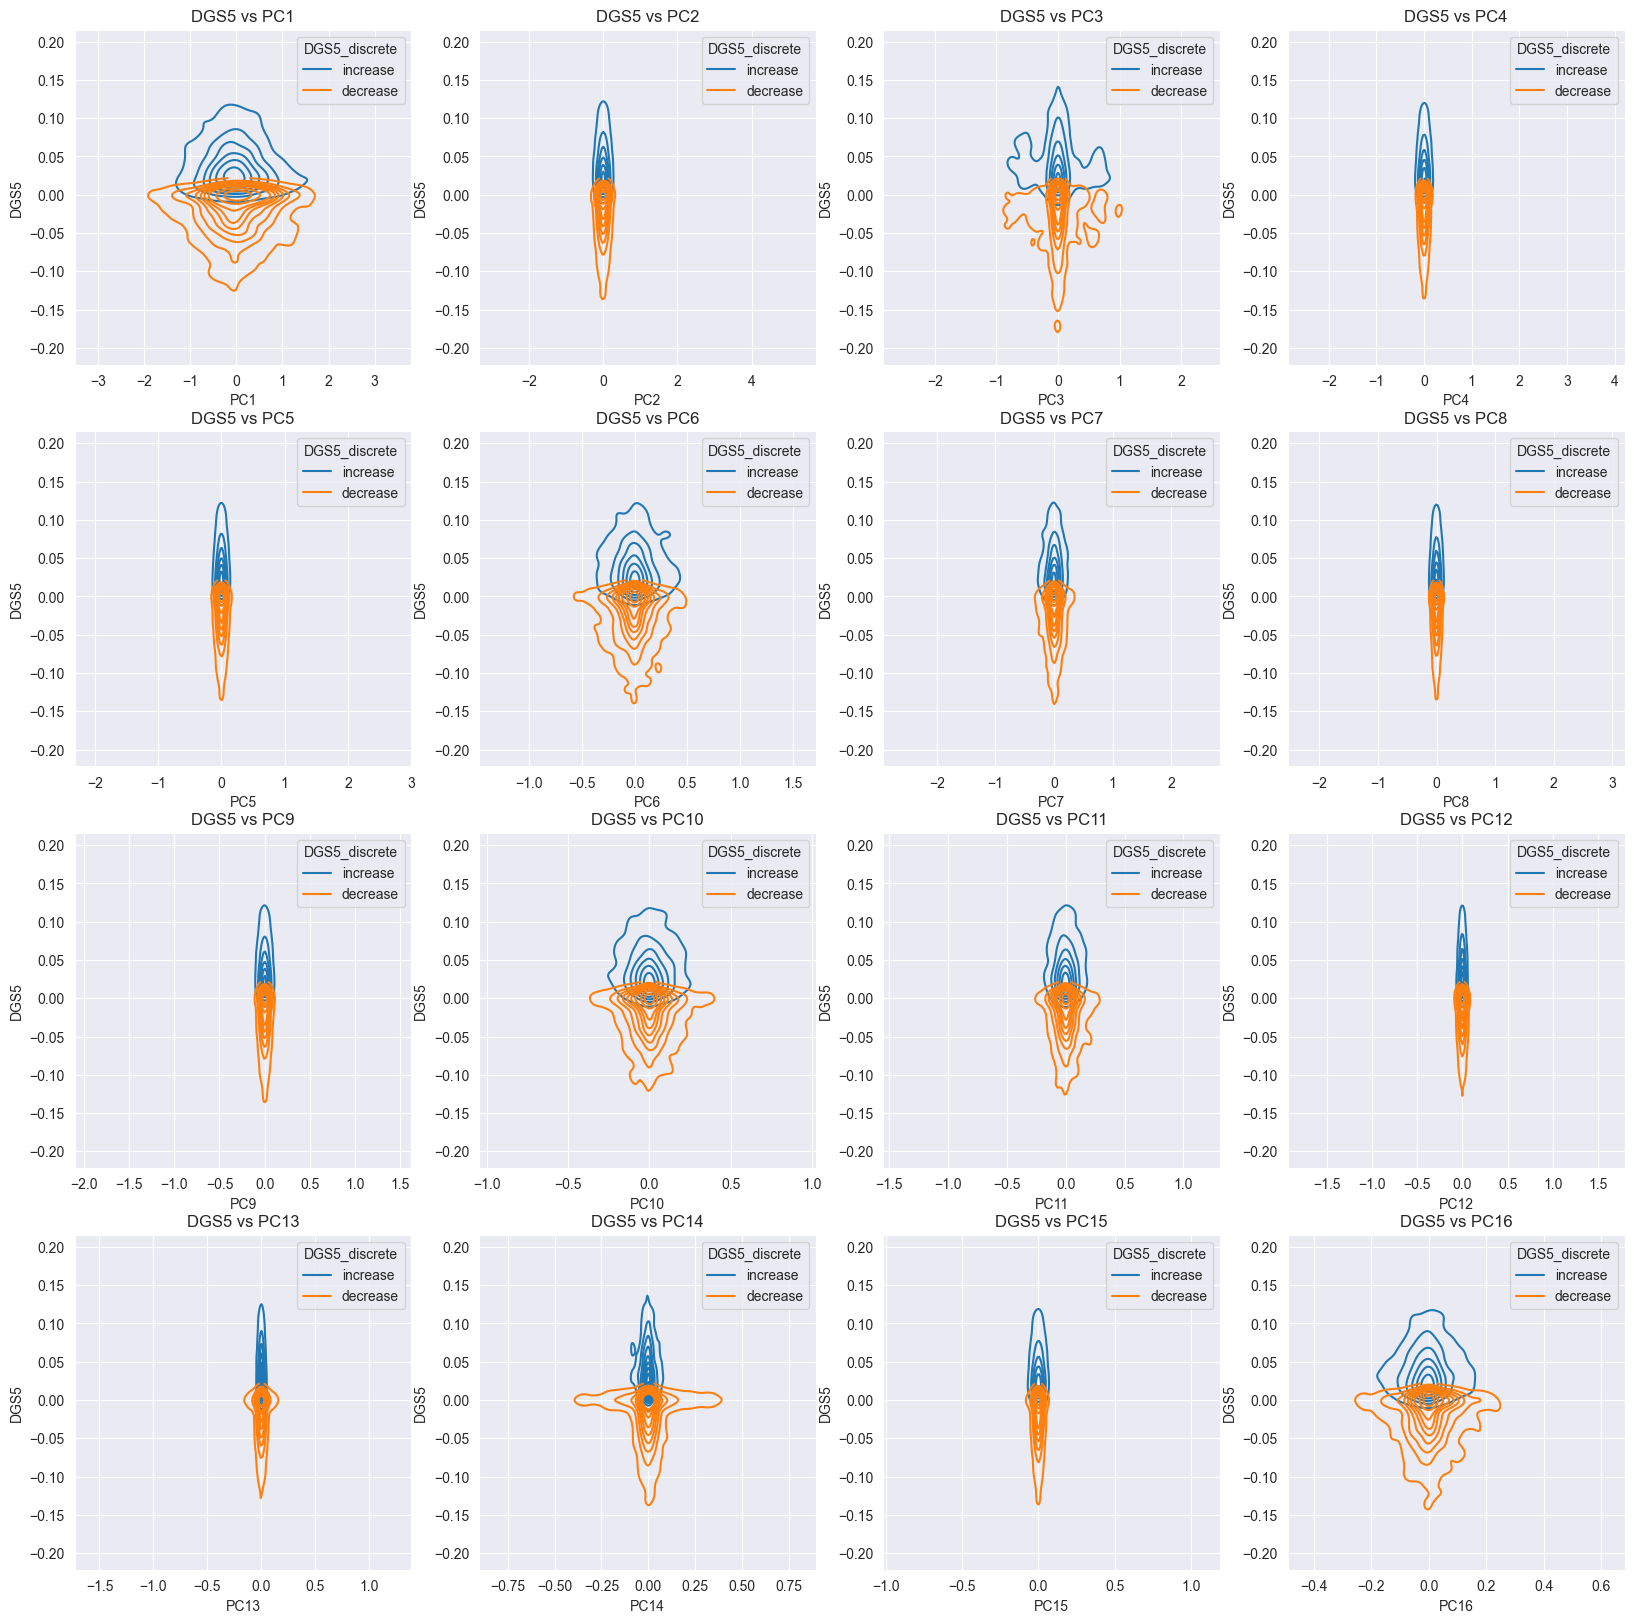

In [123]:
# create a discrete variable for each dependent variable based on whether the value is above or below 0
for dependent_var in dependent_varaibles:
    df_pca[f'{dependent_var}_discrete'] = df_pca[dependent_var].apply(lambda x: 'increase' if x > 0 else 'decrease')

# create 14 sublplots
fig, axes = plt.subplots(4, 4, figsize=(20, 20))
axes = axes.flatten()

# dependent_varaibles = [
#     'DGS1MO', 'DGS3MO', 'DGS6MO', 'DGS1', 'DGS2', 'DGS3', 'DGS5', 'DGS7', 'DGS10', 'DGS20', 'DGS30'
# ]
dependent_var = 'DGS5'
# for each dependent variable, plot the scatter plot against each principal component
for i, pca_col in enumerate(pca_columns):
    sns.kdeplot(data=df_pca, x=pca_col, y=dependent_var, hue=f'{dependent_var}_discrete', ax=axes[i])
    axes[i].set_title(f'{dependent_var} vs {pca_col}')
plt.tight_layout()


In [115]:
df_train_diff

,DGS1MO,DGS3MO,DGS6MO,DGS1,DGS2,DGS3,DGS5,DGS7,DGS10,DGS20,...,LNS14000031_diff,LNS14000006_diff,UMCSENT_diff,MICH_diff,VMTD11_diff,M1V_diff,M2V_diff,DEXVZUS_diff,WEI_diff,USAUCSFRCONDOSMSAMID_diff
period,,,,,,,,,,,,,,,,,,,,,
2011-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-01-02,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-01-03,0.04,0.03,0.00,0.00,0.00,0.01,0.01,0.03,0.06,0.05,...,-0.04,-0.03,0.003,-0.4,-0.01911,0.229,0.017,0.000000e+00,0.067,0.009116
2011-01-04,0.01,-0.01,0.00,-0.01,0.02,0.01,-0.01,-0.02,0.00,0.03,...,0.00,0.00,0.000,0.0,0.00000,0.000,0.000,0.000000e+00,0.000,0.000000
2011-01-05,0.01,0.00,0.00,0.03,0.08,0.12,0.13,0.14,0.14,0.13,...,0.00,0.00,0.000,0.0,0.00000,0.000,0.000,0.000000e+00,0.000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-12-27,-0.03,-0.01,-0.02,-0.02,-0.05,-0.05,-0.04,-0.05,-0.02,-0.01,...,0.00,0.00,0.000,0.0,0.00000,0.000,0.000,-1.600000e-09,0.000,0.000000
2019-12-28,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.000,0.0,0.00000,0.000,0.000,-2.950924e-04,0.000,0.000000
2019-12-29,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.000,0.0,0.00000,0.000,0.000,2.950940e-04,0.000,0.000000
